# ECE227 Project: Network Resilience in Multi-Robot Systems Under Adversarial Jamming

This notebook simulates a **Stochastic Block Model (SBM)** network of robots under threshold-based contagion (adversarial spoofing) and evaluates various resilience mechanisms.

### Experiments
1. **Topological Resilience** — vary *K* (number of groups) and *p_out*
2. **Deployment Strategy** — vary calibration node count and distribution
3. **Attack Robustness** — vary attack intensity and distribution
4. **Dynamic Defense** — compare static vs. dynamic link severance
5. **Threshold & Recovery Sensitivity** — vary α, β, threshold *m*, recovery *r*
6. **Bonus: Spectral Analysis** — algebraic connectivity λ₂ vs. peak infection

## 0. Imports & Global Configuration

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# ── Global parameters ──────────────────────────────────────────────────────
N    = 100   # Total number of robots
RUNS = 100    # Monte Carlo runs per configuration (increase to 100 for final results)

np.random.seed(42)
print(f"N={N} robots | {RUNS} Monte Carlo runs per configuration")

N=100 robots | 100 Monte Carlo runs per configuration


## 1. Network & Agent Setup

### 1.1 `generate_network` — Stochastic Block Model

Builds the communication graph using SBM:
- **p_in** : intra-group connection probability (default 0.6)
- **p_out** : inter-group connection probability (the key resilience variable)

In [2]:
def generate_network(N: int, K: int, p_in: float, p_out: float) -> nx.Graph:
    """
    Generate a Stochastic Block Model (SBM) network.

    Parameters
    ----------
    N     : total number of robots
    K     : number of groups
    p_in  : intra-group connection probability
    p_out : inter-group connection probability

    Returns
    -------
    G : NetworkX graph with node attribute 'group' in [0..K-1]
    """
    sizes = [N // K] * K
    sizes[-1] += N - sum(sizes)   # absorb remainder into last group

    p_matrix = [[p_out] * K for _ in range(K)]
    for i in range(K):
        p_matrix[i][i] = p_in

    G = nx.stochastic_block_model(sizes, p_matrix, seed=None)

    # Tag each node with its group
    group_id, count = 0, 0
    for node in G.nodes():
        G.nodes[node]['group'] = group_id
        count += 1
        if count >= sizes[group_id]:
            group_id = min(group_id + 1, K - 1)
            count = 0
    return G


# Quick sanity check
G_test = generate_network(N=20, K=4, p_in=0.6, p_out=0.05)
print(f"Test graph: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")

Test graph: 20 nodes, 31 edges


### 1.2 `initialize_agents` — Seed Infections & Calibration Nodes

- **Calibration nodes**: always state = 0 (GPS/ground-station equivalent)
- **Attack seeds**: initial infected nodes
- **distribution**: `'concentrated'` (all in group 0) or `'scattered'` (random)

In [3]:
def initialize_agents(G: nx.Graph,
                       attack_count: int,
                       attack_distribution: str,
                       calib_count: int,
                       calib_distribution: str,
                       K: int):
    """
    Set initial states and designate calibration nodes.

    Returns
    -------
    state     : dict {node: 0 (healthy) or 1 (infected)}
    calib_set : set of calibration node IDs (permanently state=0)
    """
    state = {n: 0 for n in G.nodes()}
    calib_set = set()

    by_group = defaultdict(list)
    for n in G.nodes():
        by_group[G.nodes[n]['group']].append(n)

    # ── Place calibration nodes ──
    if calib_distribution == 'concentrated':
        candidates = by_group[0]
    else:   # scattered – spread across groups
        candidates = []
        per_group = max(1, calib_count // K)
        for g in range(K):
            candidates.extend(by_group[g][:per_group])

    calib_set = set(np.random.choice(
        candidates, size=min(calib_count, len(candidates)), replace=False))

    # ── Place initial infections (cannot be calib nodes) ──
    if attack_distribution == 'concentrated':
        pool = [n for n in by_group[0] if n not in calib_set]
    else:
        pool = [n for n in G.nodes() if n not in calib_set]

    infected_seeds = set(np.random.choice(
        pool, size=min(attack_count, len(pool)), replace=False))
    for n in infected_seeds:
        state[n] = 1

    return state, calib_set

## 2. Core Simulation Engine

### Infection Rule (from proposal)

$$\text{score} = \alpha \cdot \frac{|\text{infected in-group neighbours}|}{|\text{in-group neighbours}|} + \beta \cdot \frac{|\text{infected out-group neighbours}|}{|\text{out-group neighbours}|} \geq \text{threshold}$$

### Recovery Rule
- Connected to a calibration node **OR** ≥ *r* healthy out-group neighbours → recover with probability *p_c*

### Dynamic Defense (optional)
- If out-group infection rate > *severance_h*, temporarily sever that edge

In [4]:
def run_simulation(G: nx.Graph,
                   state: dict,
                   calib_set: set,
                   alpha: float = 0.5,
                   beta: float = 0.5,
                   threshold: float = 0.4,
                   r: int = 2,
                   p_c: float = 0.8,
                   use_dynamic_defense: bool = False,
                   severance_h: float = 0.6,
                   max_steps: int = 200) -> dict:
    """
    Synchronous threshold contagion simulation.

    Returns
    -------
    dict with keys: infection_over_time, convergence_step,
                    peak_infection, final_infection
    """
    G_sim = G.copy()
    cur_state = state.copy()
    infection_over_time = []
    prev_state = None

    for step in range(max_steps):
        n_nodes = G_sim.number_of_nodes()
        infected_count = sum(cur_state.values())
        infection_over_time.append(infected_count / n_nodes)

        if prev_state is not None and cur_state == prev_state:
            break
        prev_state = cur_state.copy()
        new_state = cur_state.copy()

        for node in G_sim.nodes():
            if node in calib_set:          # calibration nodes never change
                new_state[node] = 0
                continue

            group = G_sim.nodes[node]['group']
            neighbors = list(G_sim.neighbors(node))
            in_nb  = [n for n in neighbors if G_sim.nodes[n]['group'] == group]
            out_nb = [n for n in neighbors if G_sim.nodes[n]['group'] != group]

            # ── Infection ──
            if cur_state[node] == 0:
                in_rate  = (sum(cur_state[n] for n in in_nb)  / len(in_nb)  if in_nb  else 0.0)
                out_rate = (sum(cur_state[n] for n in out_nb) / len(out_nb) if out_nb else 0.0)
                if alpha * in_rate + beta * out_rate >= threshold:
                    new_state[node] = 1

            # ── Recovery ──
            else:
                near_calib  = any(n in calib_set for n in neighbors)
                healthy_out = sum(1 for n in out_nb if cur_state[n] == 0)
                if near_calib or healthy_out >= r:
                    if np.random.random() < p_c:
                        new_state[node] = 0

            # ── Dynamic defense (optional) ──
            if use_dynamic_defense and out_nb:
                out_inf_rate = sum(cur_state[n] for n in out_nb) / len(out_nb)
                if out_inf_rate > severance_h:
                    for n in out_nb:
                        if G_sim.has_edge(node, n):
                            G_sim.remove_edge(node, n)

        cur_state = new_state

    while len(infection_over_time) < max_steps:
        infection_over_time.append(infection_over_time[-1])

    conv_step = next((i for i in range(1, len(infection_over_time))
                      if infection_over_time[i] == infection_over_time[i-1]), -1)

    return {
        'infection_over_time': infection_over_time,
        'convergence_step':    conv_step,
        'peak_infection':      max(infection_over_time),
        'final_infection':     infection_over_time[-1],
    }

### 2.1 Monte Carlo Wrapper

In [5]:
def monte_carlo(runs: int, **kwargs) -> dict:
    """
    Run the simulation `runs` times and aggregate statistics.
    All generate_network / initialize_agents / run_simulation parameters
    are passed through **kwargs.
    """
    peaks, finals, convs, curves = [], [], [], []

    N_mc   = kwargs['N']
    K      = kwargs['K']
    p_in   = kwargs.get('p_in', 0.6)
    p_out  = kwargs['p_out']

    for _ in range(runs):
        G = generate_network(N_mc, K, p_in, p_out)
        state, calib_set = initialize_agents(
            G,
            kwargs.get('attack_count', 2),
            kwargs.get('attack_distribution', 'concentrated'),
            kwargs.get('calib_count', 2),
            kwargs.get('calib_distribution', 'scattered'),
            K
        )
        res = run_simulation(
            G, state, calib_set,
            alpha=kwargs.get('alpha', 0.5),
            beta=kwargs.get('beta', 0.5),
            threshold=kwargs.get('threshold', 0.4),
            r=kwargs.get('r', 2),
            p_c=kwargs.get('p_c', 0.8),
            use_dynamic_defense=kwargs.get('use_dynamic_defense', False),
            severance_h=kwargs.get('severance_h', 0.6),
            max_steps=kwargs.get('max_steps', 200),
        )
        peaks.append(res['peak_infection'])
        finals.append(res['final_infection'])
        convs.append(res['convergence_step'])
        curves.append(res['infection_over_time'])

    return {
        'mean_peak':  np.mean(peaks),
        'std_peak':   np.std(peaks),
        'mean_final': np.mean(finals),
        'std_final':  np.std(finals),
        'mean_conv':  np.mean([c for c in convs if c != -1] or [200]),
        'mean_curve': np.mean(curves, axis=0),
    }

print("Core simulation functions defined ✓")

Core simulation functions defined ✓


## 3. Experiment 1 — Topological Resilience

**Research question:** For a given attack, which combination of *K* (number of groups) and *p_out* (inter-group connection probability) minimises infection spread?

**Fixed:** p_in = 0.6, attack_count = 2 (concentrated), calib_count = 2 (scattered)  
**Varied:** K ∈ {2, 4, 6, 8, 10}, p_out ∈ [0.01, 0.15]  
**Output:** Heatmap of peak and final infection rates

In [6]:
K_list      = [2, 4, 6, 8, 10]
p_out_range = np.linspace(0.01, 0.15, 8)

heat_peak  = np.zeros((len(K_list), len(p_out_range)))
heat_final = np.zeros((len(K_list), len(p_out_range)))

for i, K in enumerate(K_list):
    for j, p_out in enumerate(p_out_range):
        res = monte_carlo(RUNS, N=N, K=K, p_in=0.6, p_out=p_out,
                          attack_count=2, attack_distribution='concentrated',
                          calib_count=2, calib_distribution='scattered')
        heat_peak[i, j]  = res['mean_peak']
        heat_final[i, j] = res['mean_final']
        print(f"K={K:2d}, p_out={p_out:.3f}  →  peak={res['mean_peak']:.3f}, "
              f"final={res['mean_final']:.3f}")

print("\nExperiment 1 data collection complete ✓")

K= 2, p_out=0.010  →  peak=0.023, final=0.014
K= 2, p_out=0.030  →  peak=0.022, final=0.009
K= 2, p_out=0.050  →  peak=0.021, final=0.005
K= 2, p_out=0.070  →  peak=0.020, final=0.003
K= 2, p_out=0.090  →  peak=0.020, final=0.001
K= 2, p_out=0.110  →  peak=0.020, final=0.002
K= 2, p_out=0.130  →  peak=0.020, final=0.002
K= 2, p_out=0.150  →  peak=0.020, final=0.001
K= 4, p_out=0.010  →  peak=0.026, final=0.021
K= 4, p_out=0.030  →  peak=0.021, final=0.010
K= 4, p_out=0.050  →  peak=0.020, final=0.005
K= 4, p_out=0.070  →  peak=0.020, final=0.003
K= 4, p_out=0.090  →  peak=0.020, final=0.002
K= 4, p_out=0.110  →  peak=0.020, final=0.002
K= 4, p_out=0.130  →  peak=0.020, final=0.002
K= 4, p_out=0.150  →  peak=0.020, final=0.001
K= 6, p_out=0.010  →  peak=0.026, final=0.023
K= 6, p_out=0.030  →  peak=0.021, final=0.008
K= 6, p_out=0.050  →  peak=0.020, final=0.003
K= 6, p_out=0.070  →  peak=0.020, final=0.002
K= 6, p_out=0.090  →  peak=0.020, final=0.002
K= 6, p_out=0.110  →  peak=0.020, 

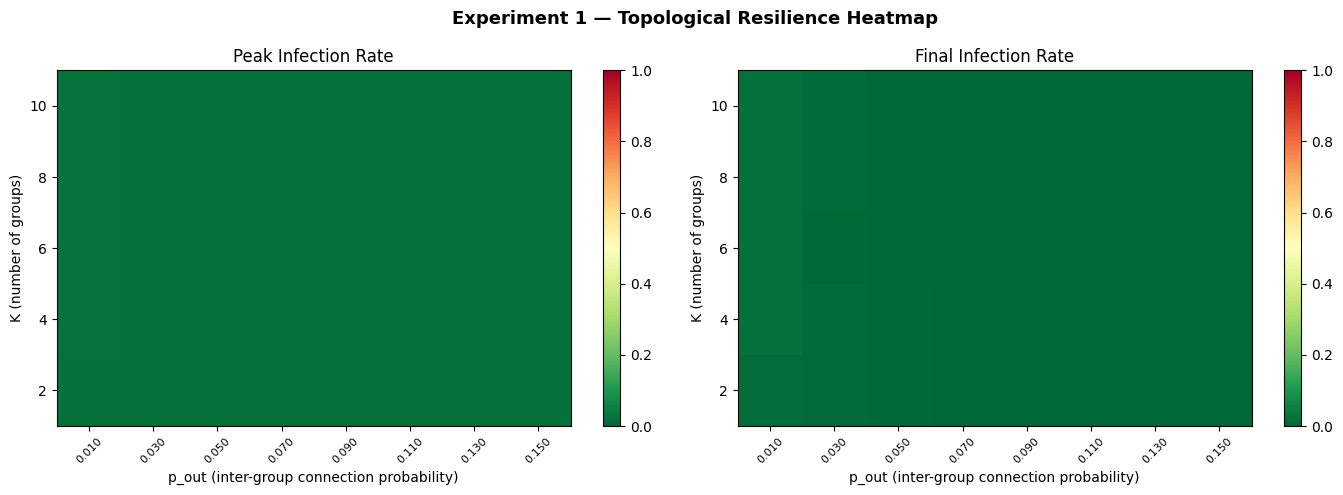

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes,
                            [heat_peak, heat_final],
                            ['Peak Infection Rate', 'Final Infection Rate']):
    im = ax.imshow(data, aspect='auto', origin='lower', cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xticks(range(len(p_out_range)))
    ax.set_xticklabels([f'{v:.3f}' for v in p_out_range], rotation=45, fontsize=8)
    ax.set_yticks(range(len(K_list)))
    ax.set_yticklabels(K_list)
    ax.set_xlabel('p_out (inter-group connection probability)')
    ax.set_ylabel('K (number of groups)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('Experiment 1 — Topological Resilience Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Experiment 2 — Calibration Node Deployment Strategy

**Research question:** Does scattering calibration nodes across groups outperform concentrating them in one group? How many calibration nodes are needed?

**Fixed:** K=4, p_in=0.6, p_out=0.05, attack_count=4 (concentrated)  
**Varied:** calib_count ∈ {1,2,4,6,10}, distribution ∈ {concentrated, scattered}  
**Output:** Convergence time, peak infection, final infection vs. calib count

In [8]:
calib_counts  = [1, 2, 4, 6, 10]
distributions = ['concentrated', 'scattered']
colors_exp2   = {'concentrated': 'crimson', 'scattered': 'steelblue'}
exp2_results  = {d: {'conv': [], 'peak': [], 'final': []} for d in distributions}

for dist in distributions:
    for cnt in calib_counts:
        res = monte_carlo(RUNS, N=N, K=4, p_in=0.6, p_out=0.05,
                          attack_count=4, attack_distribution='concentrated',
                          calib_count=cnt, calib_distribution=dist)
        exp2_results[dist]['conv'].append(res['mean_conv'])
        exp2_results[dist]['peak'].append(res['mean_peak'])
        exp2_results[dist]['final'].append(res['mean_final'])
        print(f"dist={dist:13s}, calib={cnt:2d}  →  "
              f"conv={res['mean_conv']:.1f}, peak={res['mean_peak']:.3f}")

print("\nExperiment 2 data collection complete ✓")

dist=concentrated , calib= 1  →  conv=2.5, peak=0.040
dist=concentrated , calib= 2  →  conv=2.4, peak=0.040
dist=concentrated , calib= 4  →  conv=2.6, peak=0.040
dist=concentrated , calib= 6  →  conv=2.7, peak=0.040
dist=concentrated , calib=10  →  conv=2.5, peak=0.040
dist=scattered    , calib= 1  →  conv=2.5, peak=0.040
dist=scattered    , calib= 2  →  conv=2.6, peak=0.040
dist=scattered    , calib= 4  →  conv=2.7, peak=0.040
dist=scattered    , calib= 6  →  conv=2.8, peak=0.040
dist=scattered    , calib=10  →  conv=2.8, peak=0.040

Experiment 2 data collection complete ✓


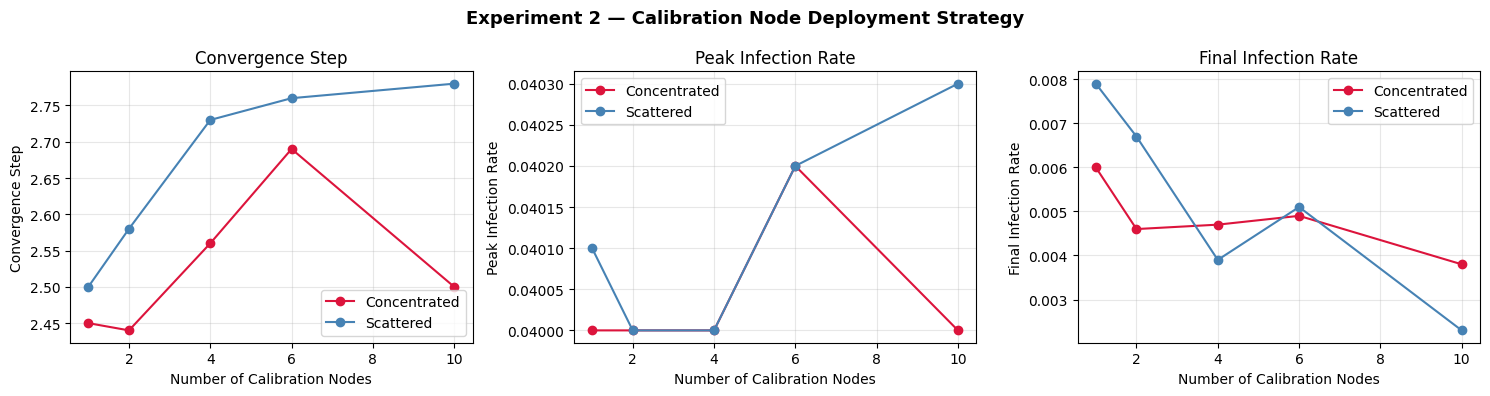

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('conv', 'Convergence Step'), ('peak', 'Peak Infection Rate'), ('final', 'Final Infection Rate')]

for ax, (metric, ylabel) in zip(axes, metrics):
    for dist in distributions:
        ax.plot(calib_counts, exp2_results[dist][metric],
                marker='o', label=dist.capitalize(), color=colors_exp2[dist])
    ax.set_xlabel('Number of Calibration Nodes')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 2 — Calibration Node Deployment Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Experiment 3 — Attack Robustness

**Research question:** At what attack intensity does the system undergo cascade collapse? Does concentrated vs. scattered attack matter?

**Fixed:** K=4, p_in=0.6, p_out=0.05, calib_count=2 (scattered)  
**Varied:** attack_count ∈ {1,2,4,6,8,12,16,20}, distribution ∈ {concentrated, scattered}  
**Output:** Peak and final infection vs. attack intensity curves

In [10]:
attack_intensities   = [1, 2, 4, 6, 8, 12, 16, 20]
attack_distributions = ['concentrated', 'scattered']
colors_exp3          = {'concentrated': 'crimson', 'scattered': 'steelblue'}
exp3_results         = {d: {'peak': [], 'final': [], 'conv': []} for d in attack_distributions}

for dist in attack_distributions:
    for intensity in attack_intensities:
        res = monte_carlo(RUNS, N=N, K=4, p_in=0.6, p_out=0.05,
                          attack_count=intensity, attack_distribution=dist,
                          calib_count=2, calib_distribution='scattered')
        exp3_results[dist]['peak'].append(res['mean_peak'])
        exp3_results[dist]['final'].append(res['mean_final'])
        exp3_results[dist]['conv'].append(res['mean_conv'])
        print(f"dist={dist:13s}, attack={intensity:2d}  →  peak={res['mean_peak']:.3f}")

print("\nExperiment 3 data collection complete ✓")

dist=concentrated , attack= 1  →  peak=0.010
dist=concentrated , attack= 2  →  peak=0.020
dist=concentrated , attack= 4  →  peak=0.040
dist=concentrated , attack= 6  →  peak=0.060
dist=concentrated , attack= 8  →  peak=0.080
dist=concentrated , attack=12  →  peak=0.120
dist=concentrated , attack=16  →  peak=0.160
dist=concentrated , attack=20  →  peak=0.200
dist=scattered    , attack= 1  →  peak=0.010
dist=scattered    , attack= 2  →  peak=0.020
dist=scattered    , attack= 4  →  peak=0.040
dist=scattered    , attack= 6  →  peak=0.060
dist=scattered    , attack= 8  →  peak=0.080
dist=scattered    , attack=12  →  peak=0.120
dist=scattered    , attack=16  →  peak=0.160
dist=scattered    , attack=20  →  peak=0.200

Experiment 3 data collection complete ✓


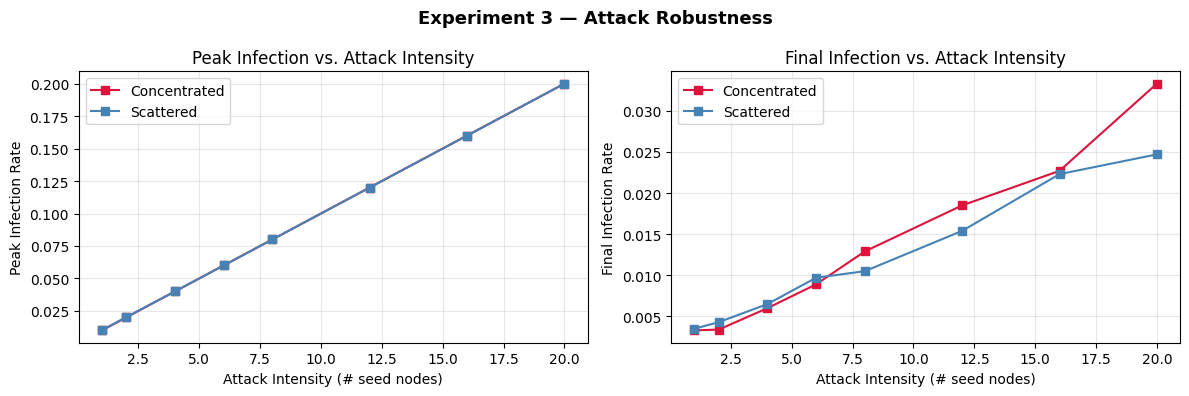

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for dist in attack_distributions:
    axes[0].plot(attack_intensities, exp3_results[dist]['peak'],
                 marker='s', label=dist.capitalize(), color=colors_exp3[dist])
    axes[1].plot(attack_intensities, exp3_results[dist]['final'],
                 marker='s', label=dist.capitalize(), color=colors_exp3[dist])

for ax, title, ylabel in zip(axes,
    ['Peak Infection vs. Attack Intensity', 'Final Infection vs. Attack Intensity'],
    ['Peak Infection Rate', 'Final Infection Rate']):
    ax.set_xlabel('Attack Intensity (# seed nodes)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 3 — Attack Robustness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Experiment 4 — Dynamic Defense Efficiency

**Research question:** Does dynamically severing links to heavily-infected out-group nodes reduce damage? What is the optimal severance threshold *h*?

**Fixed:** K=4, p_in=0.6, p_out=0.07, attack_count=5 (concentrated), calib_count=2 (scattered)  
**Varied:** severance_h ∈ [0.3, 0.8]  
**Baseline:** same network with no dynamic defense

In [12]:
severance_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

static_res = monte_carlo(RUNS, N=N, K=4, p_in=0.6, p_out=0.07,
                          attack_count=5, attack_distribution='concentrated',
                          calib_count=2, calib_distribution='scattered',
                          use_dynamic_defense=False)

dyn_peaks, dyn_finals, dyn_convs = [], [], []

for h in severance_thresholds:
    res = monte_carlo(RUNS, N=N, K=4, p_in=0.6, p_out=0.07,
                      attack_count=5, attack_distribution='concentrated',
                      calib_count=2, calib_distribution='scattered',
                      use_dynamic_defense=True, severance_h=h)
    dyn_peaks.append(res['mean_peak'])
    dyn_finals.append(res['mean_final'])
    dyn_convs.append(res['mean_conv'])
    print(f"severance_h={h:.2f}  →  peak={res['mean_peak']:.3f}, final={res['mean_final']:.3f}")

print(f"\nStatic baseline  →  peak={static_res['mean_peak']:.3f}, "
      f"final={static_res['mean_final']:.3f}")
print("\nExperiment 4 data collection complete ✓")

severance_h=0.30  →  peak=0.050, final=0.004
severance_h=0.40  →  peak=0.050, final=0.004
severance_h=0.50  →  peak=0.050, final=0.004
severance_h=0.60  →  peak=0.050, final=0.002
severance_h=0.70  →  peak=0.050, final=0.003
severance_h=0.80  →  peak=0.050, final=0.004

Static baseline  →  peak=0.050, final=0.003

Experiment 4 data collection complete ✓


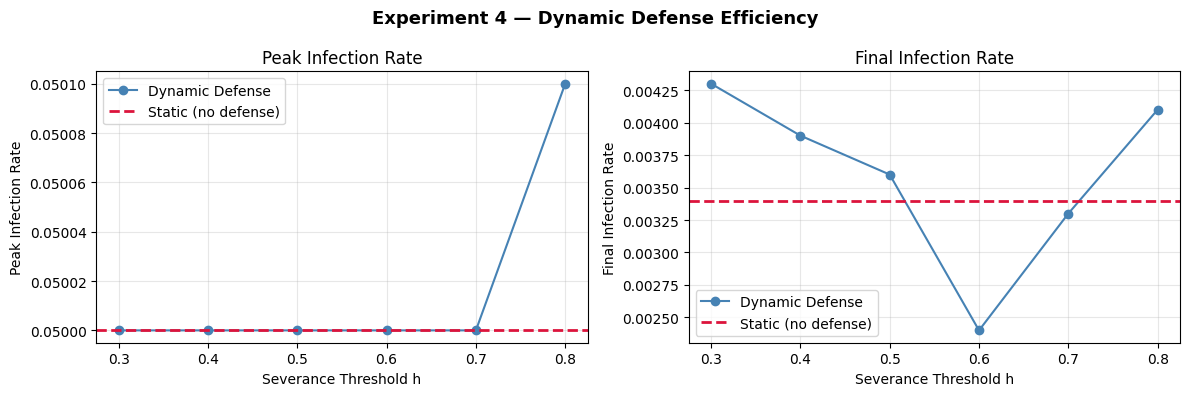

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, dyn, stat, title in zip(
    axes,
    [dyn_peaks, dyn_finals],
    [static_res['mean_peak'], static_res['mean_final']],
    ['Peak Infection Rate', 'Final Infection Rate']
):
    ax.plot(severance_thresholds, dyn, marker='o', color='steelblue', label='Dynamic Defense')
    ax.axhline(stat, color='crimson', linestyle='--', linewidth=2, label='Static (no defense)')
    ax.set_xlabel('Severance Threshold h')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 4 — Dynamic Defense Efficiency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Experiment 5 — Infection Threshold & α/β Weight Sensitivity

**Research question:** How do the weighting of in-group vs. out-group infection (α, β) and the infection threshold affect resilience?

**Fixed:** K=4, p_in=0.6, p_out=0.05, attack_count=4, calib_count=2  
**Varied:** (α, β) ∈ {(0.7,0.3), (0.5,0.5), (0.3,0.7)}, threshold ∈ [0.2, 0.7]  
**Output:** Peak and final infection vs. threshold for each (α, β) pair

In [14]:
alpha_beta_pairs = [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7)]
thresholds       = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
colors_exp5      = plt.cm.tab10(np.linspace(0, 0.5, len(alpha_beta_pairs)))
exp5_results     = {}

for (a, b) in alpha_beta_pairs:
    peaks, finals = [], []
    for thr in thresholds:
        res = monte_carlo(RUNS, N=N, K=4, p_in=0.6, p_out=0.05,
                          attack_count=4, attack_distribution='concentrated',
                          calib_count=2, calib_distribution='scattered',
                          alpha=a, beta=b, threshold=thr)
        peaks.append(res['mean_peak'])
        finals.append(res['mean_final'])
        print(f"α={a}, β={b}, thresh={thr:.2f}  →  peak={res['mean_peak']:.3f}")
    exp5_results[(a, b)] = {'peaks': peaks, 'finals': finals}

print("\nExperiment 5 data collection complete ✓")

α=0.7, β=0.3, thresh=0.20  →  peak=0.041
α=0.7, β=0.3, thresh=0.30  →  peak=0.040
α=0.7, β=0.3, thresh=0.40  →  peak=0.040
α=0.7, β=0.3, thresh=0.50  →  peak=0.040
α=0.7, β=0.3, thresh=0.60  →  peak=0.040
α=0.7, β=0.3, thresh=0.70  →  peak=0.040
α=0.5, β=0.5, thresh=0.20  →  peak=0.073
α=0.5, β=0.5, thresh=0.30  →  peak=0.040
α=0.5, β=0.5, thresh=0.40  →  peak=0.040
α=0.5, β=0.5, thresh=0.50  →  peak=0.040
α=0.5, β=0.5, thresh=0.60  →  peak=0.040
α=0.5, β=0.5, thresh=0.70  →  peak=0.040
α=0.3, β=0.7, thresh=0.20  →  peak=0.522
α=0.3, β=0.7, thresh=0.30  →  peak=0.043
α=0.3, β=0.7, thresh=0.40  →  peak=0.040
α=0.3, β=0.7, thresh=0.50  →  peak=0.040
α=0.3, β=0.7, thresh=0.60  →  peak=0.040
α=0.3, β=0.7, thresh=0.70  →  peak=0.040

Experiment 5 data collection complete ✓


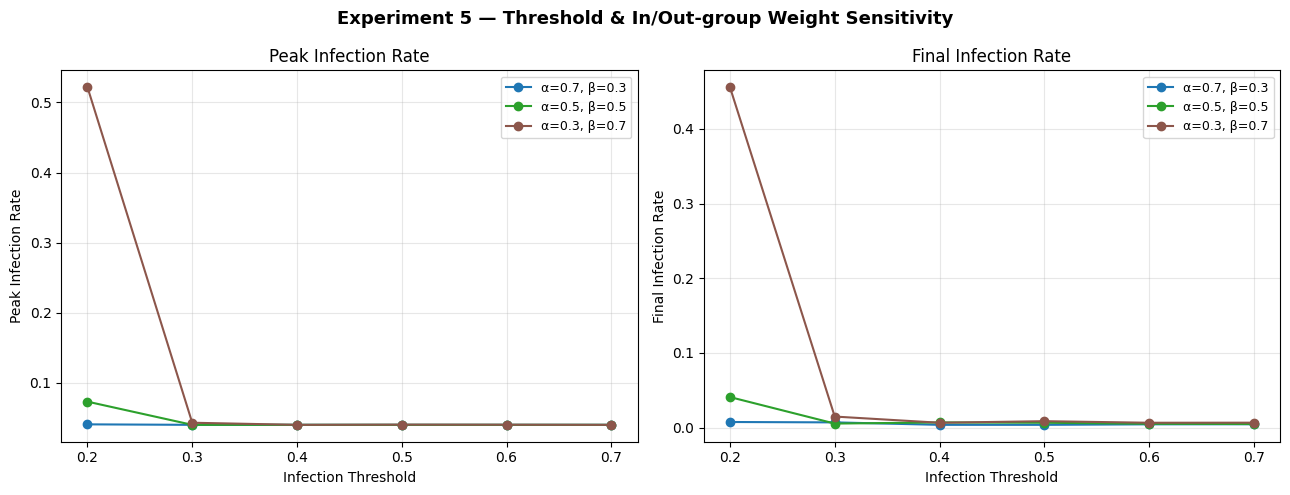

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (a, b), color in zip(alpha_beta_pairs, colors_exp5):
    lbl = f'α={a}, β={b}'
    axes[0].plot(thresholds, exp5_results[(a,b)]['peaks'],  marker='o', color=color, label=lbl)
    axes[1].plot(thresholds, exp5_results[(a,b)]['finals'], marker='o', color=color, label=lbl)

for ax, title in zip(axes, ['Peak Infection Rate', 'Final Infection Rate']):
    ax.set_xlabel('Infection Threshold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 5 — Threshold & In/Out-group Weight Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Bonus — Spectral Analysis: Algebraic Connectivity λ₂ vs. Peak Infection

The **algebraic connectivity** (second smallest eigenvalue of the Laplacian, λ₂) measures how well-connected the network is. This experiment asks: does a higher λ₂ (tighter network) lead to faster collapse under attack?

In [16]:
p_out_spectral = np.linspace(0.005, 0.20, 15)
K_spectral     = 4
trials         = 20

lambdas_list, peaks_list = [], []

for p_out in p_out_spectral:
    lam2_buf, pk_buf = [], []
    for _ in range(trials):
        G = generate_network(N, K_spectral, p_in=0.6, p_out=p_out)
        L = nx.laplacian_matrix(G).toarray()
        eigvals = np.sort(np.linalg.eigvalsh(L))
        lam2 = eigvals[1]

        state, calib_set = initialize_agents(G, 3, 'concentrated', 2, 'scattered', K_spectral)
        res = run_simulation(G, state, calib_set, max_steps=100)

        lam2_buf.append(lam2)
        pk_buf.append(res['peak_infection'])

    lambdas_list.append(np.mean(lam2_buf))
    peaks_list.append(np.mean(pk_buf))
    print(f"p_out={p_out:.3f}  →  λ₂={lambdas_list[-1]:.4f}, peak={peaks_list[-1]:.3f}")

print("\nSpectral analysis complete ✓")

p_out=0.005  →  λ₂=0.2764, peak=0.034
p_out=0.019  →  λ₂=1.3434, peak=0.034
p_out=0.033  →  λ₂=2.5001, peak=0.030
p_out=0.047  →  λ₂=3.6830, peak=0.031
p_out=0.061  →  λ₂=4.6991, peak=0.031
p_out=0.075  →  λ₂=5.8746, peak=0.030
p_out=0.089  →  λ₂=7.0157, peak=0.030
p_out=0.103  →  λ₂=8.4425, peak=0.030
p_out=0.116  →  λ₂=9.5252, peak=0.030
p_out=0.130  →  λ₂=10.7022, peak=0.030
p_out=0.144  →  λ₂=11.5408, peak=0.030
p_out=0.158  →  λ₂=12.9462, peak=0.030
p_out=0.172  →  λ₂=13.5401, peak=0.030
p_out=0.186  →  λ₂=14.6813, peak=0.030
p_out=0.200  →  λ₂=16.0165, peak=0.030

Spectral analysis complete ✓


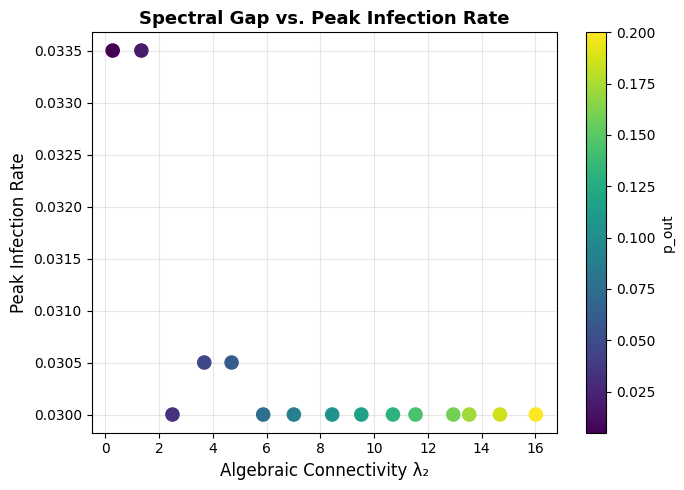

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(lambdas_list, peaks_list, c=p_out_spectral, cmap='viridis', s=90, zorder=3)
plt.colorbar(sc, ax=ax, label='p_out')
ax.set_xlabel('Algebraic Connectivity λ₂', fontsize=12)
ax.set_ylabel('Peak Infection Rate', fontsize=12)
ax.set_title('Spectral Gap vs. Peak Infection Rate', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

| Experiment | Key Takeaway |
|---|---|
| 1. Topological | Optimal K and p_out minimises infection heatmap |
| 2. Deployment | Scattered calibration nodes reduce convergence time |
| 3. Attack Robustness | Concentrated attacks cause faster cascade collapse |
| 4. Dynamic Defense | Optimal severance threshold h exists per topology |
| 5. Threshold Sensitivity | Higher α (in-group weight) delays spread when group is healthy |
| Bonus | Higher λ₂ correlates with faster/wider infection spread |